# Binary Segmentation Visualizer

Run inference on any image with any trained binary vessel model and inspect predictions in all three supported output formats:
1. **Detectron** — bounding boxes, class IDs, confidence scores
2. **ARCADE** — polygon segmentations in ARCADE annotation space
3. **Label Studio** — RLE-encoded masks for pre-annotation import

Each format includes a dedicated visualization cell.

In [ ]:
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2 import model_zoo

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from coro_dt.config import ParamsConfig, apply_pointrend_overrides
from coro_dt.data.formatters import format_detectron, format_arcade, format_labelstudio

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

VESSEL_COLOR = (0.2, 0.6, 1.0)
VESSEL_RGB = np.array(VESSEL_COLOR) * 255

## Configuration

Set the paths and parameters below, then run all cells.

In [90]:
IMAGE_PATH = '/Users/piotrswiecik/dev/ives/coronary/datasets/arcade/syntax/test/images/35.png'
MODEL_PATH = '/Users/piotrswiecik/dev/ives/coronary/detectron-master/trained_models/binary_epochs_60_batch_2_dt_20260213_102312/model_final.pth'
PARAMS_FILE = '../params.json'
THRESHOLD = 0.5
USE_CPU = True

SAVE_FIGURES = True
FIGURES_DIR = './figures'

In [ ]:
with open(PARAMS_FILE) as f:
    params = ParamsConfig(**json.load(f))

cfg = get_cfg()

if params.use_pointrend:
    from detectron2.projects.point_rend import add_pointrend_config
    add_pointrend_config(cfg)

cfg.merge_from_file(model_zoo.get_config_file(params.backbone.value))
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1
cfg.MODEL.WEIGHTS = MODEL_PATH
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = THRESHOLD
cfg.MODEL.ANCHOR_GENERATOR.SIZES = params.anchor_sizes
cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = params.anchor_ratios
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = params.roi_batch_size
cfg.MODEL.BACKBONE.FREEZE_AT = params.freeze_at

if params.use_pointrend:
    apply_pointrend_overrides(cfg, num_classes=1)

if USE_CPU:
    cfg.MODEL.DEVICE = 'cpu'

predictor = DefaultPredictor(cfg)
print(f'Model loaded: {MODEL_PATH}')
print(f'Backbone: {params.backbone.value}')
if params.use_pointrend:
    print('PointRend mask head: enabled')

In [92]:
im = cv2.imread(IMAGE_PATH)
assert im is not None, f'Could not read image: {IMAGE_PATH}'
h, w = im.shape[:2]
stem = os.path.splitext(os.path.basename(IMAGE_PATH))[0]

if SAVE_FIGURES:
    os.makedirs(FIGURES_DIR, exist_ok=True)
    print(f'Figures will be saved to {os.path.abspath(FIGURES_DIR)}/')

outputs = predictor(im)
instances = outputs['instances']
print(f'Image: {IMAGE_PATH} ({w}x{h})')
print(f'Detected instances: {len(instances)}')

Figures will be saved to /Users/piotrswiecik/dev/ives/coronary/detectron-master/notebooks/figures/
Image: /Users/piotrswiecik/dev/ives/coronary/datasets/arcade/syntax/test/images/35.png (512x512)
Detected instances: 6


---
## 1. Detectron format

Raw bounding boxes, class IDs, and confidence scores.

In [72]:
det_result = format_detectron(instances, IMAGE_PATH)
print(json.dumps(det_result, indent=2))

{
  "image": "/Users/piotrswiecik/dev/ives/coronary/datasets/arcade/syntax/test/images/3.png",
  "num_instances": 5,
  "instances": [
    {
      "bbox": [
        216.69268798828125,
        219.59188842773438,
        431.81939697265625,
        419.17218017578125
      ],
      "category_id": 0,
      "score": 0.992298424243927
    },
    {
      "bbox": [
        102.64806365966797,
        125.35871124267578,
        173.1719512939453,
        177.4245147705078
      ],
      "category_id": 0,
      "score": 0.990426242351532
    },
    {
      "bbox": [
        157.50491333007812,
        136.5902862548828,
        243.60745239257812,
        240.94259643554688
      ],
      "category_id": 0,
      "score": 0.940555214881897
    },
    {
      "bbox": [
        177.72035217285156,
        233.87991333007812,
        258.5242004394531,
        427.6051330566406
      ],
      "category_id": 0,
      "score": 0.9047588109970093
    },
    {
      "bbox": [
        164.32275390625,

Saved 3_detectron.png


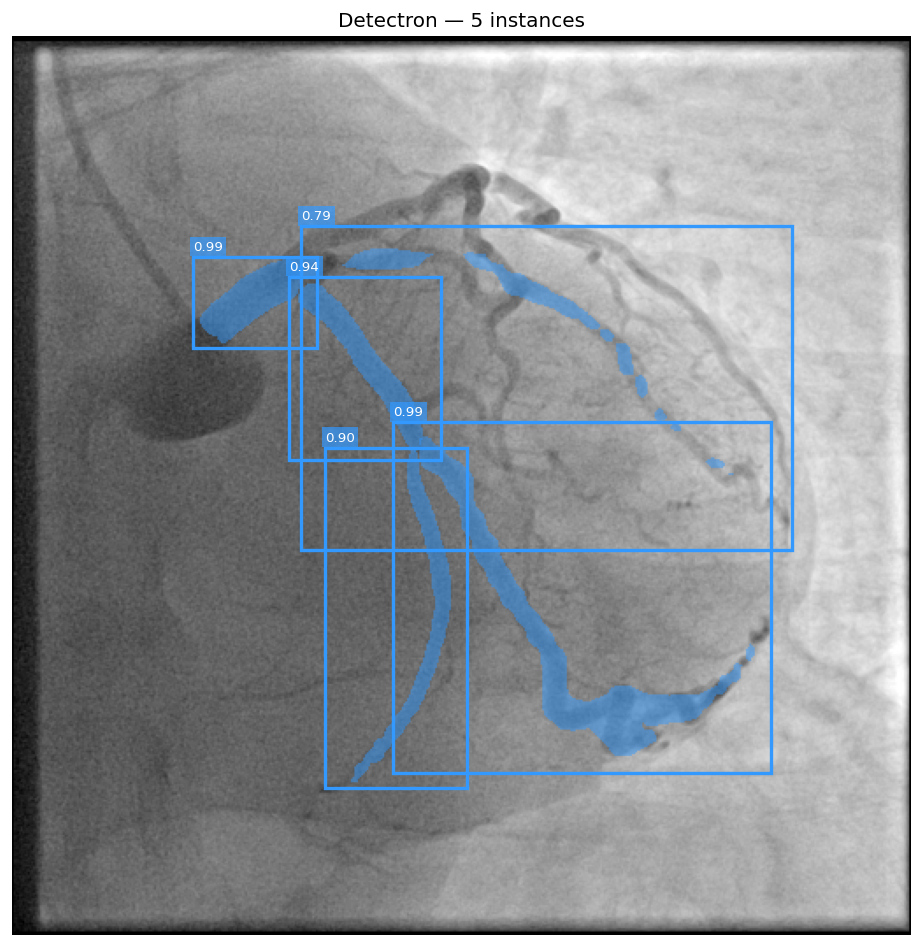

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
display_img = cv2.cvtColor(im, cv2.COLOR_BGR2RGB).copy().astype(np.float32)

cpu_inst = instances.to('cpu')
det_masks = cpu_inst.pred_masks.numpy() if cpu_inst.has('pred_masks') else []

for mask in det_masks:
    if mask.shape != (h, w):
        mask = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST).astype(bool)
    display_img[mask] = display_img[mask] * 0.5 + VESSEL_RGB * 0.5

ax.imshow(display_img.astype(np.uint8))
ax.set_title(f'Detectron \u2014 {len(det_result["instances"])} instances')
ax.axis('off')

for inst in det_result['instances']:
    x1, y1, x2, y2 = inst['bbox']
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=VESSEL_COLOR, facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(
        x1, y1 - 4, f'{inst["score"]:.2f}',
        fontsize=8, color='white',
        bbox=dict(facecolor=VESSEL_COLOR, alpha=0.7, pad=2, edgecolor='none')
    )

plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(os.path.join(FIGURES_DIR, f'{stem}_detectron.png'), dpi=150, bbox_inches='tight')
    print(f'Saved {stem}_detectron.png')
plt.show()

---
## 2. ARCADE format

Polygon segmentations mapped to ARCADE annotation space.

In [93]:
arcade_result = format_arcade(instances, image_id=0, height=h, width=w)
print(json.dumps(arcade_result, indent=2))

{
  "image_id": 0,
  "annotations": [
    {
      "id": 1,
      "image_id": 0,
      "category_id": 0,
      "segmentation": [
        187.0,
        41.0,
        186.0,
        42.0,
        182.0,
        42.0,
        181.0,
        43.0,
        179.0,
        43.0,
        178.0,
        44.0,
        176.0,
        44.0,
        175.0,
        45.0,
        173.0,
        45.0,
        172.0,
        46.0,
        164.0,
        46.0,
        163.0,
        45.0,
        162.0,
        45.0,
        161.0,
        44.0,
        158.0,
        44.0,
        157.0,
        43.0,
        147.0,
        43.0,
        146.0,
        44.0,
        144.0,
        44.0,
        143.0,
        45.0,
        143.0,
        47.0,
        142.0,
        48.0,
        142.0,
        53.0,
        144.0,
        55.0,
        145.0,
        55.0,
        146.0,
        56.0,
        147.0,
        56.0,
        149.0,
        58.0,
        149.0,
        60.0,
        155.0,
        60.0,
  

Saved 35_arcade.png


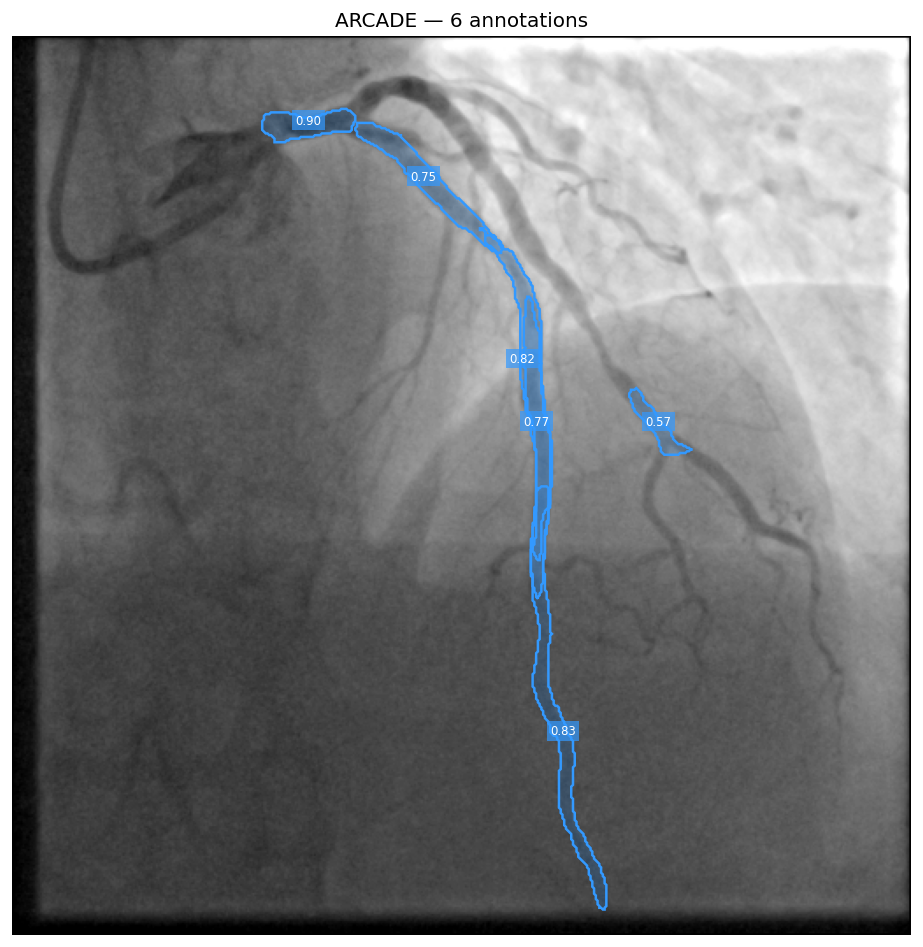

In [94]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
ax.set_title(f'ARCADE \u2014 {len(arcade_result["annotations"])} annotations')
ax.axis('off')

for ann in arcade_result['annotations']:
    seg = ann['segmentation']
    pts = np.array(seg).reshape(-1, 2)
    poly = patches.Polygon(
        pts, closed=True, linewidth=1.5,
        edgecolor=VESSEL_COLOR, facecolor=(*VESSEL_COLOR, 0.2)
    )
    ax.add_patch(poly)
    cx, cy = pts.mean(axis=0)
    ax.text(
        cx, cy, f'{ann["score"]:.2f}',
        fontsize=7, color='white', ha='center',
        bbox=dict(facecolor=VESSEL_COLOR, alpha=0.7, pad=2, edgecolor='none')
    )

plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(os.path.join(FIGURES_DIR, f'{stem}_arcade.png'), dpi=150, bbox_inches='tight')
    print(f'Saved {stem}_arcade.png')
plt.show()

---
## 3. Label Studio format

RLE-encoded masks for Label Studio pre-annotation import.  
Requires `label-studio-converter` (`pip install -e '.[labelstudio]'`).

In [10]:
ls_result = format_labelstudio(instances, orig_height=h, orig_width=w)
# RLE arrays are large \u2014 print summary instead of full dump
summary = {
    'num_results': len(ls_result['result']),
    'overall_score': ls_result['score'],
    'per_mask': [
        {
            'id': r['id'],
            'brushlabels': r['value']['brushlabels'],
            'rle_length': len(r['value']['rle']),
            'score': r['score'],
        }
        for r in ls_result['result']
    ],
}
print(json.dumps(summary, indent=2))

{
  "num_results": 4,
  "overall_score": 0.8889863789081573,
  "per_mask": [
    {
      "id": "cbb1620e",
      "brushlabels": [
        "vessel"
      ],
      "rle_length": 844,
      "score": 0.9667500257492065
    },
    {
      "id": "f8a7aebc",
      "brushlabels": [
        "vessel"
      ],
      "rle_length": 241,
      "score": 0.944543182849884
    },
    {
      "id": "ae6f1322",
      "brushlabels": [
        "vessel"
      ],
      "rle_length": 620,
      "score": 0.9102066159248352
    },
    {
      "id": "ff32a535",
      "brushlabels": [
        "vessel"
      ],
      "rle_length": 215,
      "score": 0.7344456911087036
    }
  ]
}


In [ ]:
cpu_instances = instances.to('cpu')
masks = cpu_instances.pred_masks.numpy()
scores = cpu_instances.scores.numpy()

n_masks = len(masks)
cols = min(n_masks, 4)
rows = (n_masks + cols - 1) // cols if n_masks > 0 else 1

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
fig.suptitle(f'Label Studio \u2014 {n_masks} masks (overall score: {ls_result["score"]:.2f})', fontsize=12)

for idx in range(rows * cols):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    if idx < n_masks:
        mask = masks[idx]
        if mask.shape != (h, w):
            mask = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST).astype(bool)
        overlay = cv2.cvtColor(im, cv2.COLOR_BGR2RGB).copy()
        overlay[mask] = (overlay[mask] * 0.4 + VESSEL_RGB * 0.6).astype(np.uint8)
        ax.imshow(overlay)
        ax.set_title(f'mask {idx} \u2014 score {scores[idx]:.2f}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(os.path.join(FIGURES_DIR, f'{stem}_labelstudio.png'), dpi=150, bbox_inches='tight')
    print(f'Saved {stem}_labelstudio.png')
plt.show()

---
## Combined overlay

All masks composited on the original image with bounding boxes.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
overlay = cv2.cvtColor(im, cv2.COLOR_BGR2RGB).copy().astype(np.float32)

for idx in range(len(masks)):
    mask = masks[idx]
    if mask.shape != (h, w):
        mask = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST).astype(bool)
    overlay[mask] = overlay[mask] * 0.5 + VESSEL_RGB * 0.5

ax.imshow(overlay.astype(np.uint8))

for inst in det_result['instances']:
    x1, y1, x2, y2 = inst['bbox']
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=VESSEL_COLOR, facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(
        x1, y1 - 4, f'vessel {inst["score"]:.2f}',
        fontsize=8, color='white',
        bbox=dict(facecolor=VESSEL_COLOR, alpha=0.8, pad=2, edgecolor='none')
    )

ax.set_title(f'Combined \u2014 {len(masks)} instances', fontsize=12)
ax.axis('off')
plt.tight_layout()
if SAVE_FIGURES:
    fig.savefig(os.path.join(FIGURES_DIR, f'{stem}_combined.png'), dpi=150, bbox_inches='tight')
    print(f'Saved {stem}_combined.png')
plt.show()

---
## Export to file

Save any of the three formats to disk.

In [ ]:
EXPORT_FORMAT = 'detectron'  # 'detectron', 'arcade', or 'labelstudio'

results_map = {
    'detectron': det_result,
    'arcade': arcade_result,
    'labelstudio': ls_result,
}

stem = os.path.splitext(os.path.basename(IMAGE_PATH))[0]
out_path = f'{stem}_{EXPORT_FORMAT}.json'

with open(out_path, 'w') as f:
    json.dump(results_map[EXPORT_FORMAT], f, indent=2)

print(f'Saved {EXPORT_FORMAT} prediction to {os.path.abspath(out_path)}')